In [88]:
import pandas as pd
import numpy as np
pswm = pd.read_csv("pswm_final.csv", index_col=0)
pswm.columns = pswm.columns.astype(int)

print(pswm.shape)
print(pswm.index)
print(pswm.columns)

(20, 15)
Index(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q',
       'R', 'S', 'T', 'V', 'W', 'Y'],
      dtype='object')
Index([-13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1], dtype='int64')


In [89]:
def read_fasta_to_dict():
    seqs = {}
    with open("benchmark.fasta", "r") as f:
        current_id = None
        current_seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    seqs[current_id] = "".join(current_seq)
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None: 
            seqs[current_id] = "".join(current_seq) 
    return seqs
bench= read_fasta_to_dict()

def score_bench(bench, pswm):
 
    pswm_arr = pswm.to_numpy()
    aa_to_idx = {aa: i for i, aa in enumerate(pswm.index)}
    pos_to_idx = {pos: i for i, pos in enumerate(pswm.columns)}

    window_size = 15
    index = list(range(-13, 2))
    results = {}

    for seq_id, seq in bench.items():
        seq_scores = []
        # limit sliding to first 90 aa
        max_start = min(len(seq), 90) - window_size + 1 
        for i in range(max_start):
            window = seq[i:i + window_size]
            try:
                score = 0
                for aa, pos in zip(window, index):
                    score += pswm_arr[aa_to_idx[aa], pos_to_idx[pos]]
            except KeyError:
                score = np.nan
            seq_scores.append(score)
        results[seq_id] = max(seq_scores)
    return results
scores = score_bench(bench, pswm)
print(list(scores.items())[:5])

[('P04275', 15.433734547876753), ('P04844', 13.983033765040739), ('P07359', 17.088493697076824), ('P13671', 7.792694152901856), ('P19438', 7.124579471773328)]


In [90]:
# testing the threshold on benchmarking data
info= pd.read_csv("all.tsv", sep="\t")
label_mapping = dict(zip(info["UniprotAccession"], info["label"]))
bench_labels={}
for seq_id in scores.keys():
    if seq_id in label_mapping:
        if label_mapping[seq_id] == "positive":
            bench_labels[seq_id] = 1
        else:
            bench_labels[seq_id] = 0   

In [91]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    matthews_corrcoef, confusion_matrix
)
threshold= 6.141
# Build y_true and y_pred lists
y_true = []
y_pred = []

for seq_id, score in scores.items():
    true_label = bench_labels[seq_id]      # 1 for positive, 0 for negative
    predicted_label = 1 if score >= threshold else 0

    y_true.append(true_label)
    y_pred.append(predicted_label)

# Compute metrics
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:\n", cm)
print(f"F1={f1:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, MCC={mcc:.3f}")

'''True Negatives (TN) = 1548
False Positives (FP) = 239
False Negatives (FN) = 8
True Positives (TP) = 211'''

Confusion matrix:
 [[1548  239]
 [   8  211]]
F1=0.631, Precision=0.469, Recall=0.963, MCC=0.620


'True Negatives (TN) = 1548\nFalse Positives (FP) = 239\nFalse Negatives (FN) = 8\nTrue Positives (TP) = 211'

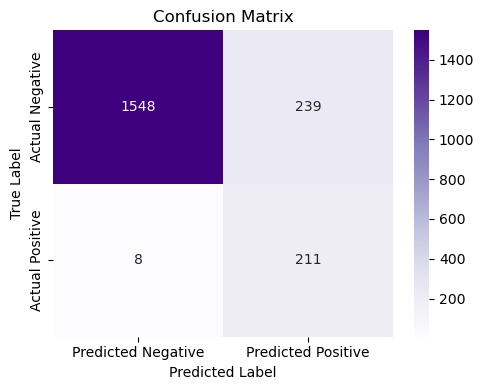

In [92]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
# Plot it
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [94]:
# Add predictions and ground truth
info["true_label"] = info["label"].map({"positive": 1, "negative": 0})
info["score"] = info["UniprotAccession"].map(scores)
info["predicted"] = (info["score"] >= threshold).astype(int)
# Compute TP, TN, FP, FN counts per kingdom
summary = (
    info.groupby("Kingdom")
    .apply(lambda x: pd.Series({
        "TP": ((x["true_label"] == 1) & (x["predicted"] == 1)).sum(),
        "TN": ((x["true_label"] == 0) & (x["predicted"] == 0)).sum(),
        "FP": ((x["true_label"] == 0) & (x["predicted"] == 1)).sum(),
        "FN": ((x["true_label"] == 1) & (x["predicted"] == 0)).sum()
    }))
    .reset_index()
)
summary


,Kingdom,TP,TN,FP,FN
0,Fungi,15,2450,25,80
1,Metazoa,167,4545,152,699
2,Other,3,163,5,25
3,Viridiplantae,26,1537,57,77


In [140]:
import matplotlib.pyplot as plt

# Define your full and error-only columns + colors
cols_all = ["TP", "TN", "FP", "FN"]
cols_errors = ["FP", "FN"]

colors_all = ["yellowgreen", "olivedrab", "darkorchid", "orchid"]  
colors_errors = ["darkorchid", "orchid"] 

for kingdom in summary_percent["Kingdom"]:
    row = summary_percent[summary_percent["Kingdom"] == kingdom].iloc[0]

    # Extract values for both sets
    values_all = row[cols_all]
    values_errors = row[cols_errors]

    # Create side-by-side donuts
    fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1]})

    # --- Donut 1: All outcomes ---
    wedges, texts, autotexts = ax[0].pie(
        values_all,
        labels=cols_all,
        autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
        startangle=90,
        colors=colors_all,
        textprops={'fontsize': 10, 'color': 'black'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
    )
    ax[0].add_artist(plt.Circle((0, 0), 0.70, fc='white'))
    ax[0].set_title(f"{kingdom} — All outcomes", fontsize=13)

    # --- Donut 2: Only FP and FN ---
    wedges, texts, autotexts = ax[1].pie(
        values_errors,
        labels=cols_errors,
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        colors=colors_errors,
        textprops={'fontsize': 10, 'color': 'black'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
    )
    ax[1].add_artist(plt.Circle((0, 0), 0.70, fc='white'))
    ax[1].set_title(f"{kingdom} — FP/FN only", fontsize=13)

    plt.tight_layout()
    plt.savefig(f"donut{kingdom}.png")

    plt.show()
    

SyntaxError: f-string: empty expression not allowed (1324571587.py, line 47)